In [ ]:
!pip install tensorflow opencv-python scikit-learn matplotlib

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_path = "/content/drive/MyDrive/sattelite/train"

In [ ]:
import os
import pandas as pd
before_path = base_path + "/A"
after_path = base_path + "/B"
label_path = base_path + "/label"
data = []
for img in os.listdir(before_path):
    data.append({
        "image_id": img,
        "before": os.path.join(before_path,img),
        "after": os.path.join(after_path,img),
        "label": os.path.join(label_path,img)
    })

df = pd.DataFrame(data)
df.head()

,image_id,before,after,label
0,train_1.png,/content/drive/MyDrive/sattelite/train/A/train...,/content/drive/MyDrive/sattelite/train/B/train...,/content/drive/MyDrive/sattelite/train/label/t...
1,train_10.png,/content/drive/MyDrive/sattelite/train/A/train...,/content/drive/MyDrive/sattelite/train/B/train...,/content/drive/MyDrive/sattelite/train/label/t...
2,train_101.png,/content/drive/MyDrive/sattelite/train/A/train...,/content/drive/MyDrive/sattelite/train/B/train...,/content/drive/MyDrive/sattelite/train/label/t...
3,train_100.png,/content/drive/MyDrive/sattelite/train/A/train...,/content/drive/MyDrive/sattelite/train/B/train...,/content/drive/MyDrive/sattelite/train/label/t...
4,train_102.png,/content/drive/MyDrive/sattelite/train/A/train...,/content/drive/MyDrive/sattelite/train/B/train...,/content/drive/MyDrive/sattelite/train/label/t...


In [ ]:
import cv2
import numpy as np
IMG_SIZE = 256
def load_data():
    X = []
    y = []
    for img in os.listdir(before_path):
        before = cv2.imread(os.path.join(before_path,img))
        after = cv2.imread(os.path.join(after_path,img))
        mask = cv2.imread(os.path.join(label_path,img),0)
        before = cv2.resize(before,(IMG_SIZE,IMG_SIZE))
        after = cv2.resize(after,(IMG_SIZE,IMG_SIZE))
        mask = cv2.resize(mask,(IMG_SIZE,IMG_SIZE))
        mask = mask / 255.0
        combined = np.concatenate([before,after],axis=2)
        X.append(combined)
        y.append(mask)
    X = np.array(X)/255.0
    y = np.array(y)
    y = np.expand_dims(y,axis=3)
    return X,y

X,y = load_data()
print(X.shape)
print(y.shape)

(445, 256, 256, 6)
(445, 256, 256, 1)


In [ ]:
def iou_metric(y_true, y_pred):

    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection

    return intersection / (union + 1e-6)

In [ ]:
import tensorflow as tf
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
def dice_coef(y_true, y_pred):

    smooth = 1e-6

    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)

    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

In [ ]:
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

def unet_model():

    inputs = Input((IMG_SIZE, IMG_SIZE, 6))

    c1 = Conv2D(16,3,activation='relu',padding='same')(inputs)
    c1 = Conv2D(16,3,activation='relu',padding='same')(c1)
    p1 = MaxPooling2D()(c1)

    c2 = Conv2D(32,3,activation='relu',padding='same')(p1)
    c2 = Conv2D(32,3,activation='relu',padding='same')(c2)
    p2 = MaxPooling2D()(c2)

    c3 = Conv2D(64,3,activation='relu',padding='same')(p2)
    c3 = Conv2D(64,3,activation='relu',padding='same')(c3)

    u1 = UpSampling2D()(c3)
    u1 = concatenate([u1,c2])
    c4 = Conv2D(32,3,activation='relu',padding='same')(u1)

    u2 = UpSampling2D()(c4)
    u2 = concatenate([u2,c1])
    c5 = Conv2D(16,3,activation='relu',padding='same')(u2)

    outputs = Conv2D(1,1,activation='sigmoid')(c5)

    return Model(inputs,outputs)

In [ ]:
model = unet_model()

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', dice_coef,iou_metric]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 6)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        880 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      2,320 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 128, 128,  │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 96)               │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │     27,680 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 256, 256,  │          0 │ conv2d_6[0][0]    │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 256, 256,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 48)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 256, 256,  │      6,928 │ concatenate_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 256, 256,  │         17 │ conv2d_7[0][0]    │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 107,137 (418.50 KB)

 Trainable params: 107,137 (418.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=4
)

Epoch 1/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 20s 73ms/step - accuracy: 0.9517 - dice_coef: 0.0400 - iou_metric: 0.0205 - loss: 0.2229 - val_accuracy: 0.9450 - val_dice_coef: 0.0539 - val_iou_metric: 0.0278 - val_loss: 0.2144
Epoch 2/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9518 - dice_coef: 0.0452 - iou_metric: 0.0232 - loss: 0.1961 - val_accuracy: 0.9450 - val_dice_coef: 0.0231 - val_iou_metric: 0.0117 - val_loss: 0.2409
Epoch 3/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9518 - dice_coef: 0.0526 - iou_metric: 0.0272 - loss: 0.1825 - val_accuracy: 0.9450 - val_dice_coef: 0.0786 - val_iou_metric: 0.0411 - val_loss: 0.1911
Epoch 4/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9518 - dice_coef: 0.0708 - iou_metric: 0.0369 - loss: 0.1684 - val_accuracy: 0.9450 - val_dice_coef: 0.0609 - val_iou_metric: 0.0314 - val_loss: 0.1873
Epoch 5/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9518 - dice_coef: 0.0939 - iou_metric: 0.0497 - loss: 0.1553 - val

In [ ]:
import matplotlib.pyplot as plt

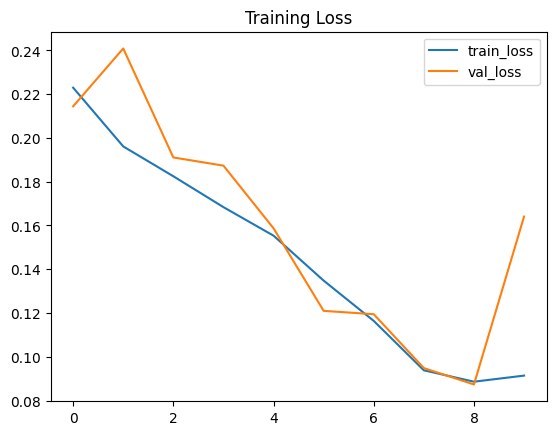

In [ ]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')

plt.legend()
plt.title("Training Loss")
plt.show()

In [ ]:
pred_mask = model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step


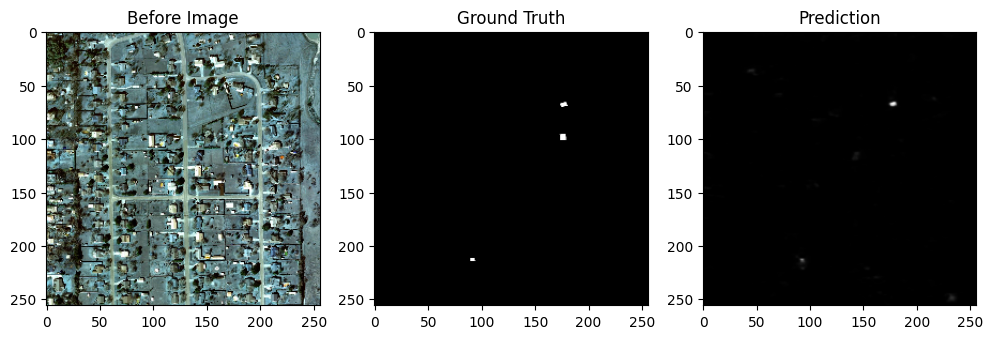

In [ ]:
idx = 0

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Before Image")
plt.imshow(X_test[idx][:,:,0:3])

plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(y_test[idx], cmap="gray")

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(pred_mask[idx].squeeze(), cmap="gray")

plt.show()

In [ ]:
model.save("change_detection_model.keras")